In [1]:
# cuda visible 
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = "1"

import torch.backends.cudnn as cudnn
cudnn.benchmark = True

In [2]:
import os 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

from CityScapes import CityscapesDataset

from DCGAN.discriminator import Discriminator
from DCGAN.encoder import Encoder
from DCGAN.reconstruction_generator import ReconstructionGenerator
from DCGAN.unet import UNet
from file_management import get_version_folder, save_config, load_config
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss, DriftLoss, EntropyLoss


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [3]:
load_run = None
config_name = 'config.yaml'

In [4]:
if load_run:
    config_path = os.path.join(load_run,config_name)
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/dcgan'
    index_folder = get_version_folder(root)
    config = load_config(config_name)
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,config_name)
    save_config(config, config_target_path)




Config saved to cache/dcgan/26/config.yaml


In [5]:
channels = config['models']['channels']
z_shape = config['models']['z_shape']
z_dim = z_shape[0]
number_of_components = config['models']['number_of_components']

enc_block_depth = config['models']['enc']['block_depth']
enc_residual = config['models']['enc']['residual']
enc_use_norm = config['models']['enc']['use_norm']

gen_block_depth = config['models']['gen']['block_depth']
gen_residual = config['models']['gen']['residual']
gen_use_norm = config['models']['gen']['use_norm']
gen_vector_dim = config['models']['gen']['vector_dim']
gen_vectorizer_linear_layer_multipliers = config['models']['gen']['linear_layer_multipliers']
gen_degrees_of_freedom = config['models']['gen']['degrees_of_freedom']

seg_gen_block_depth = config['models']['segmentation_gen']['block_depth']
seg_gen_residual = config['models']['segmentation_gen']['residual']
seg_gen_use_norm = config['models']['segmentation_gen']['use_norm']
seg_gen_cut_connections = config['models']['segmentation_gen']['cut_connections']

disc_block_depth = config['models']['disc']['block_depth']
disc_residual = config['models']['disc']['residual']
disc_use_norm = config['models']['disc']['use_norm']

batch_size = config['training']['batch_size']

enc_lr = config['training']['enc']['enc_lr']
enc_reconstruction_loss_weight = config['training']['enc']['enc_reconstruction_loss_weight']
enc_feature_loss_weight = config['training']['enc']['enc_feature_loss_weight']

gen_lr = config['training']['gen']['gen_lr']

seg_gen_lr=  config['training']['segmentation_gen']['seg_gen_lr']
seg_gen_entropy_loss_weight = config['training']['segmentation_gen']['entropy_loss_weight']

n_critic = config['training']['disc']['n_critic']
disc_lr = config['training']['disc']['disc_lr']
disc_gp_loss_weight = config['training']['disc']['disc_gp_loss_weight']
disc_drift_loss_weight = config['training']['disc']['disc_drift_loss_weight']



save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

enc_path = os.path.join(index_folder,'enc.pth')
gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')
seg_gen_path = os.path.join(index_folder,'seg_gen.pth')


tensorboard_path = os.path.join(index_folder, 'logs')
writer = SummaryWriter(log_dir=tensorboard_path)

In [6]:

enc = Encoder(channels=channels,
              block_depth=enc_block_depth,
              z_dim=z_dim,
              residual=enc_residual,
              img_channels=3,
              use_norm=enc_use_norm).to(device)

gen = ReconstructionGenerator(channels=channels,
                z_dim=z_dim,                
                number_of_components=number_of_components,
                vector_dim=gen_vector_dim,
                vectorizer_linear_layer_multipliers=gen_vectorizer_linear_layer_multipliers,
                degrees_of_freedom=gen_degrees_of_freedom,
                block_depth=enc_block_depth,
                residual=gen_residual,
                img_channels=3,
                use_norm=gen_use_norm).to(device)

seg_gen = UNet(channels=channels,
                block_depth=enc_block_depth,
                residual=gen_residual,
                number_of_components=number_of_components,
                cut_connections=seg_gen_cut_connections,
                use_norm=gen_use_norm).to(device)

disc = Discriminator(channels=channels,
                      block_depth=disc_block_depth,
                      residual=disc_residual,
                      img_channels=3,
                      use_norm=disc_use_norm).to(device)



if load_run is not None:
    enc.load_state_dict(torch.load(enc_path))
    gen.load_state_dict(torch.load(gen_path))
    seg_gen.load_state_dict(torch.load(seg_gen_path))
    disc.load_state_dict(torch.load(disc_path))





enc_optim = Adam(enc.parameters(), lr=enc_lr, betas=(0.0, 0.9))
gen_optim = Adam(gen.parameters(), lr=gen_lr, betas=(0.0, 0.9))
seg_gen_optim = Adam(seg_gen.parameters(), lr=seg_gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


tensorboard_step = 0


In [7]:
train_iter = iter(train_loader)

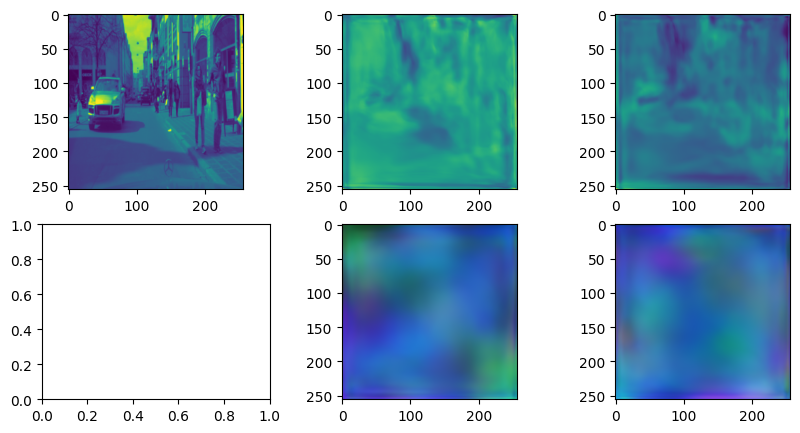

In [ ]:
data ,_ = next(train_iter)
data = data.to(device)
with torch.no_grad():
    encoded_vector = enc(data)
    reconstruction = gen(encoded_vector)
    segmentation = seg_gen(data)
    num_classes = segmentation.shape[1]

#     reconstructed_image = combine(reconstruction, segmentation)



components = reconstruction.shape[1]
fig,ax = plt.subplots(2,components+1,figsize=(10,5))
ax[0,0].imshow(data.cpu().numpy()[0,0])
for i in range(components):
    ax[0,i+1].imshow(segmentation.cpu().numpy()[0,i])


# reconstructed_image = scale_for_display(reconstructed_image)
reconstruction = scale_for_display(reconstruction)
# ax[1,0].imshow(reconstructed_image.cpu()[0].permute(1,2,0).numpy())
for i in range(components):
    ax[1,i+1].imshow(reconstruction[0,i].permute(1,2,0).cpu().numpy())
plt.show()
